# Week 1: System exploration (Group)

In the first stage, your aim is to **understand the behaviour of a system**.

You should focus on questions like:
- How do the observed signals change over time?
- How do different input patterns affect the observations?
- Are some signals more informative than others?
- What is easy to observe, and what seems hidden?

At this stage, the priority is **exploration and intuition-building**, not solving the whole project.

## Group tasks for Week 1

As a group, extend the basic experiment and **build a shared code workflow.**

Your group should aim to produce:
- a clean way to explore dataset, either from simulation or experiment,
- standard plotting functions,
- a simulation platform for studying and comparing effects of different input patterns and system dynamics (transition matrices), for example:
    - random inputs,
    - pulses,
    - oscillatory inputs,
    - activating only one input channel at a time,
    - activating different channels with different amplitudes,
    - exploring the relationship between input structure and system dynamics (such as coupling between inputs and transition matrices);
- brief documentation so that all group members can build on the same starting point.

All of the above tasks should be completed by Friday 22 May, before the scheduled check-in session.

## Week 1 deliverable

**Deliverable:** Group simulation code + brief documentation  
**Marks:** 10 group marks  
**Due:** Friday 22 May, 11am–1pm (**compulsory session**)

At the check-in session, the demonstrator will review the code and ask each member of the group questions about it. Every member of the group is therefore expected to have contributed to the code and to take full responsibility for understanding it.

## Example dataset

In [7]:
# loading dataset
import numpy as np
data = np.load("ExampleDataset.npy")
print("Dataset loaded successfully. Shape:", data.shape)  # (Trials, Timepoints, Neurons)

Dataset loaded successfully. Shape: (5, 60, 16)


## Desgin an illustrator

A class that can generate primary statistics, analyses, and visualization of any dataset. Design your illustrator in **Illustrator.py**.

To test your documentation, the demonstrator will use your illustrator here, but will never see your code (in this section). 

Please make your annotations clear and comprehensive!

In [9]:
import importlib
import Illustrator as illustrator_module

importlib.reload(illustrator_module)

Illustrator = illustrator_module.Illustrator

illu = Illustrator(data)

# 1. Basic dataset summary
illu.summary()

Dataset summary
----------------
Number of trials: 5
Number of timepoints per trial: 60
Number of neurons/signals: 16
Overall mean: 3.2349
Overall standard deviation: 3.0061
Minimum value: -2.9995
Maximum value: 11.1942


The `summary()` function reports the basic size and value range of the dataset. For the example dataset, the shape is `(5, 60, 16)`, meaning 5 trials, 60 timepoints per trial, and 16 observed channels. The values range from about -2.9995 to 11.1942, suggesting that the observed signals contain variation.

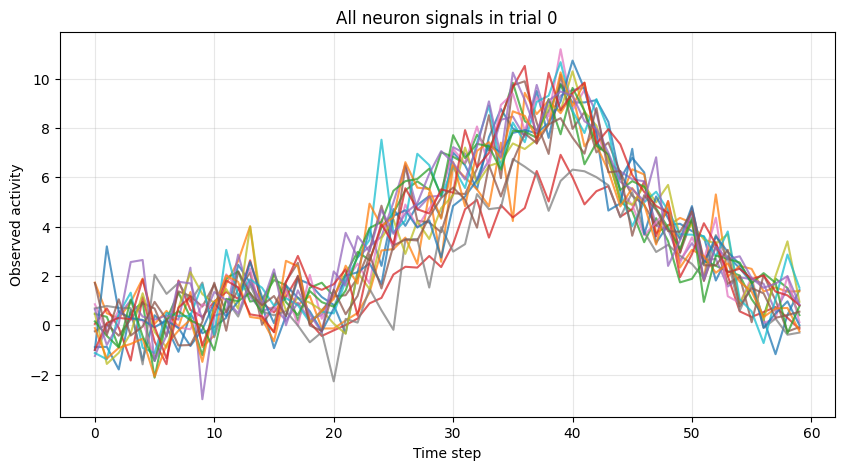

In [10]:
# 2. Plot all neurons in one trial
illu.plot_trial(trial_id=0)

The `plot_trial()` function illustrates all observed channels in one trial. In trial 0, most channels show a shared rise-and-fall pattern: activity is low at early time steps, increases after around time step 20, peaks around time step 35–40, and then decreases. This suggests that many observed neurons are driven by a common underlying structure. Therefore obervations are not purely random noise.

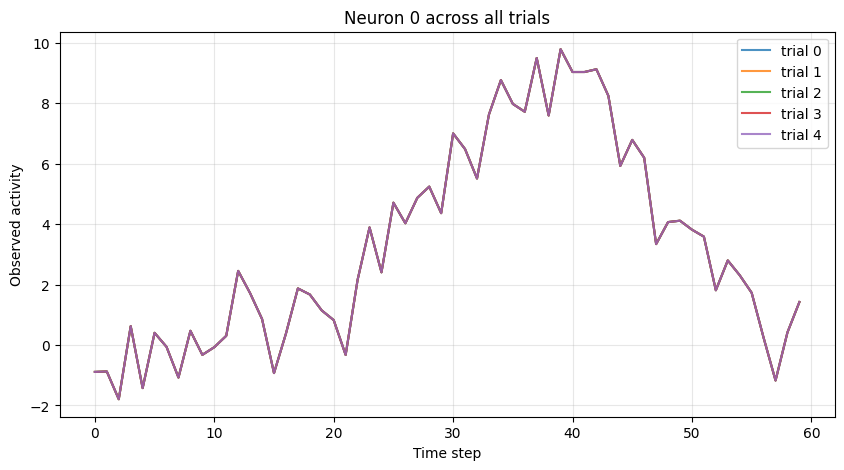

In [11]:
# 3. Plot one neuron across all trials
illu.plot_neuron(neuron_id=0)

The `plot_neuron()` function compares one neuron across all trials. For neuron 0, all five trial curves overlap exactly, suggesting no visible trial-to-trial variation for this channel. This motivated a more systematic trial variability check.

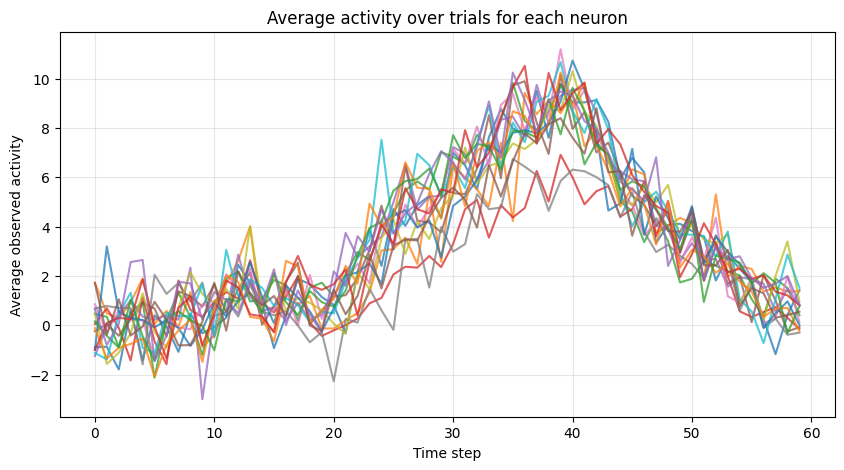

In [22]:
# 4. Plot average over trials for each neuron (same as one trial)
illu.plot_trial_average()

The `plot_trial_average()` function averages the observations across trials and plots the average time plots for each neuron. In this dataset, the averaged curves are almost identical to the single-trial curves because the five trials have zero trial-to-trial variability.

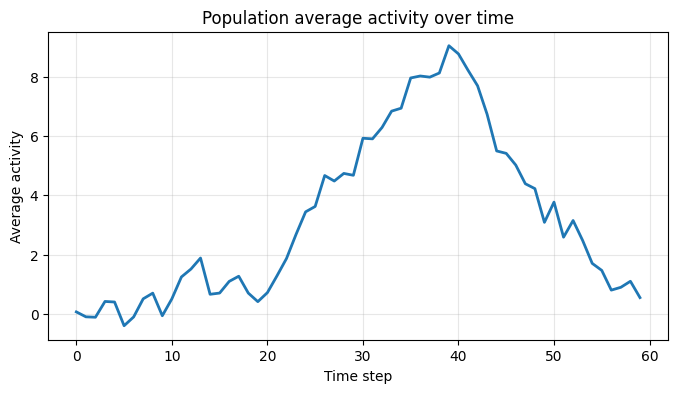

In [13]:
# 5. Plot population average over time
illu.plot_population_average()

The `plot_population_average()` function averages across all trials and all observed channels. It provides a population-level summary of the dataset. The example dataset shows a clear global rise-and-fall pattern, with activity increasing after around time step 20, peaking near time step 39, and decreasing afterwards.

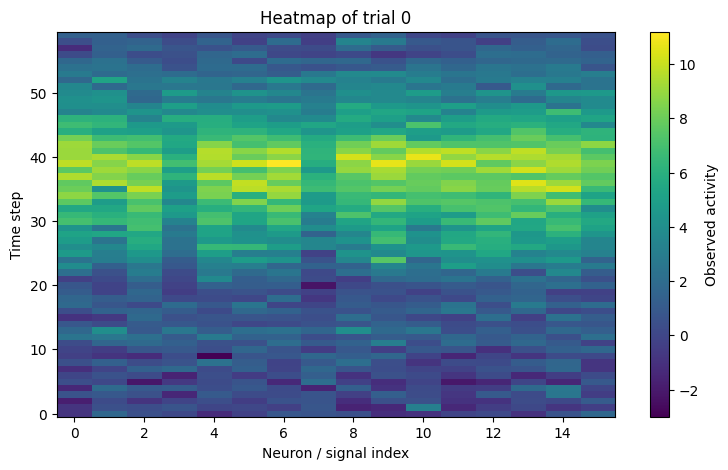

In [14]:
# 6. Plot heatmap of one trial
illu.plot_heatmap(trial_id=0)

The `plot_heatmap()` function displays one trial as a time-by-neuron image. The heatmap for trial 0 shows a strong high-activity band around time step 30–45 across many channels. This supports the interpretation that the dataset contains a shared population-level activation event.

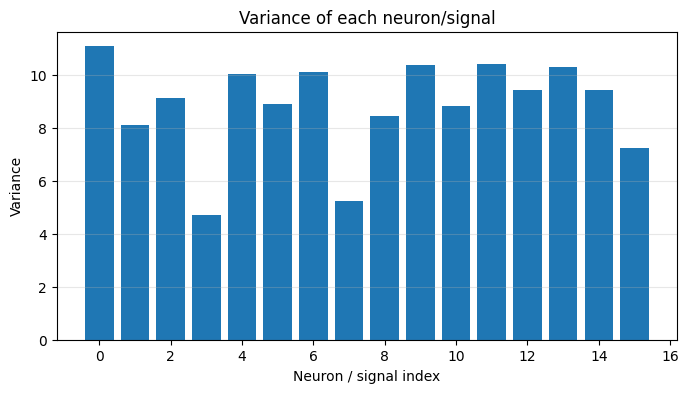

In [15]:
# 7. Plot variance of each neuron
illu.plot_neuron_variance()

The `plot_neuron_variance()` function compares the variance of each observed channel. Channels with larger variance show stronger changes and may be more informative about visible system behaviour. In the example dataset, neurons such as 0, 6, 9, 11, and 13 have relatively high variance, while neurons 3 and 7 have lower variance.

In [16]:
# 8. Print neuron-level statistics
stats = illu.neuron_statistics()

Neuron statistics
-----------------
Neuron  0: mean=3.292, std=3.331, var=11.094, peak=9.791, peak_time=39
Neuron  1: mean=3.233, std=2.849, var=8.118, peak=9.424, peak_time=36
Neuron  2: mean=3.404, std=3.026, var=9.159, peak=9.832, peak_time=35
Neuron  3: mean=2.293, std=2.171, var=4.715, peak=6.911, peak_time=39
Neuron  4: mean=3.500, std=3.170, var=10.048, peak=9.746, peak_time=37
Neuron  5: mean=3.345, std=2.983, var=8.897, peak=10.161, peak_time=39
Neuron  6: mean=3.412, std=3.182, var=10.124, peak=11.194, peak_time=39
Neuron  7: mean=2.246, std=2.288, var=5.236, peak=6.743, peak_time=35
Neuron  8: mean=3.329, std=2.908, var=8.457, peak=10.299, peak_time=40
Neuron  9: mean=3.580, std=3.223, var=10.388, peak=10.671, peak_time=39
Neuron 10: mean=3.209, std=2.972, var=8.832, peak=10.733, peak_time=40
Neuron 11: mean=3.203, std=3.230, var=10.435, peak=10.256, peak_time=39
Neuron 12: mean=3.430, std=3.072, var=9.438, peak=9.625, peak_time=40
Neuron 13: mean=3.601, std=3.213, var=10.32

The `neuron_statistics()` function provides numerical summaries for each observed neuron. Most channels peak around time step 35–40, suggesting a shared temporal event. However, the channels differ in mean activity, variance, peak value, and peak time, indicating that the observation neurons are not identical copies.

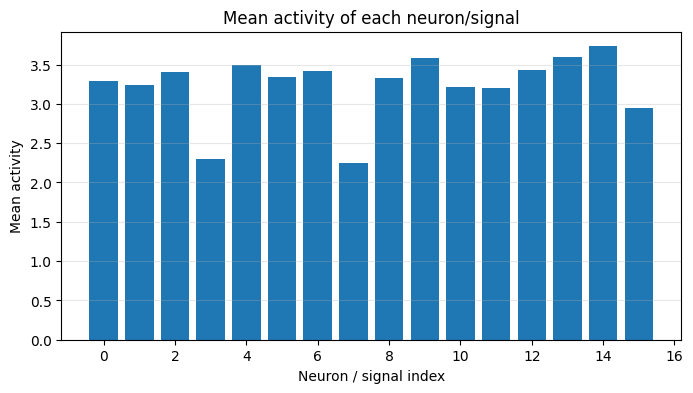

In [17]:
# 9. Plot mean activity of each neuron
illu.plot_neuron_mean_activity()

The `plot_neuron_mean_activity()` function compares the average activity level of each channel. In the example dataset, neurons 13 and 14 have relatively high mean activity, while neurons 3 and 7 have lower mean activity.

In [19]:
# 10. Trial-to-trial variability report
mean_trial_std, max_trial_std = illu.trial_variability_report()

Trial-to-trial variability report
---------------------------------
Overall mean trial std: 0.000000
Overall max trial std: 0.000000
Neuron  0: mean trial std=0.000000, max trial std=0.000000
Neuron  1: mean trial std=0.000000, max trial std=0.000000
Neuron  2: mean trial std=0.000000, max trial std=0.000000
Neuron  3: mean trial std=0.000000, max trial std=0.000000
Neuron  4: mean trial std=0.000000, max trial std=0.000000
Neuron  5: mean trial std=0.000000, max trial std=0.000000
Neuron  6: mean trial std=0.000000, max trial std=0.000000
Neuron  7: mean trial std=0.000000, max trial std=0.000000
Neuron  8: mean trial std=0.000000, max trial std=0.000000
Neuron  9: mean trial std=0.000000, max trial std=0.000000
Neuron 10: mean trial std=0.000000, max trial std=0.000000
Neuron 11: mean trial std=0.000000, max trial std=0.000000
Neuron 12: mean trial std=0.000000, max trial std=0.000000
Neuron 13: mean trial std=0.000000, max trial std=0.000000
Neuron 14: mean trial std=0.000000, max t

The `trial_variability_report()` function checks whether repeated trials differ from each other. In the example dataset, the overall mean and maximum trial standard deviation are both exactly zero. This means that all five trials are identical repeated copies. 

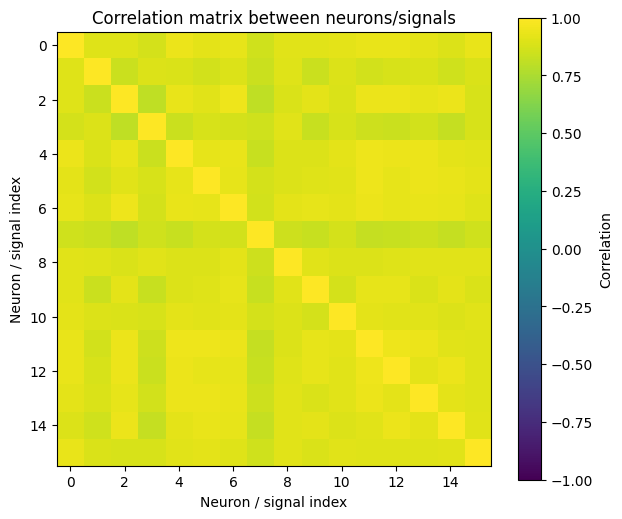

In [20]:
# 12. Correlation matrix between neurons
corr = illu.plot_correlation_matrix()

The `plot_correlation_matrix()` function measures pairwise correlations between observed channels. The example dataset shows strong positive correlations between most channels, suggesting that the 16 observed signals share a common temporal structure and may be driven by a low-dimensional latent pattern.

PCA/SVD energy
--------------
Component  1: explained=0.9111, cumulative=0.9111
Component  2: explained=0.0187, cumulative=0.9298
Component  3: explained=0.0109, cumulative=0.9407
Component  4: explained=0.0090, cumulative=0.9496
Component  5: explained=0.0081, cumulative=0.9577
Component  6: explained=0.0068, cumulative=0.9645
Component  7: explained=0.0063, cumulative=0.9708
Component  8: explained=0.0053, cumulative=0.9762
Component  9: explained=0.0047, cumulative=0.9809
Component 10: explained=0.0043, cumulative=0.9852
Component 11: explained=0.0036, cumulative=0.9888
Component 12: explained=0.0031, cumulative=0.9919
Component 13: explained=0.0027, cumulative=0.9947
Component 14: explained=0.0023, cumulative=0.9969
Component 15: explained=0.0017, cumulative=0.9986
Component 16: explained=0.0014, cumulative=1.0000


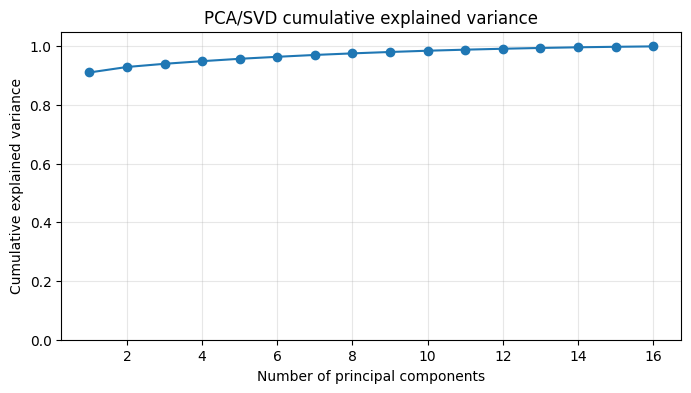

In [21]:
# 13. PCA/SVD energy analysis
explained, cumulative = illu.pca_energy()

The `pca_energy()` function uses SVD/PCA to check whether high-dimensional observations have low-dimensional structure. In the example dataset, the first principal component explains 91.11% of the total variance. This suggests that the 16 observed channels are dominated by one shared direction of variation. 

## Design a simulator

In GG4, we use a simple linear model:
$$
x_{t+1} = Ax_t + Bu_t + w_t, w_t \sim \mathcal{N}(0, Q)
$$
$$
y_t = Cx_t + o_t, o_t \sim \mathcal{N}(0, R)
$$

Your simulator should be able to simulate observation of any length given different parameters.

Design your simulator in **Simulator.py**.

To test your documentation, the demonstrator will use your simulator here, but will never see your code (in this section). 
Please make your annotations clear and comprehensive!

Combining the illustrator and simulator, what's your findings? Illustrate them.
This forms your answer to the question: "effects of different input patterns and system dynamics"

In [13]:
import importlib
import Simulator as sim

importlib.reload(sim)

<module 'Simulator' from '/Users/ameciouslee/Desktop/IIA/GG4/Simulator.py'>

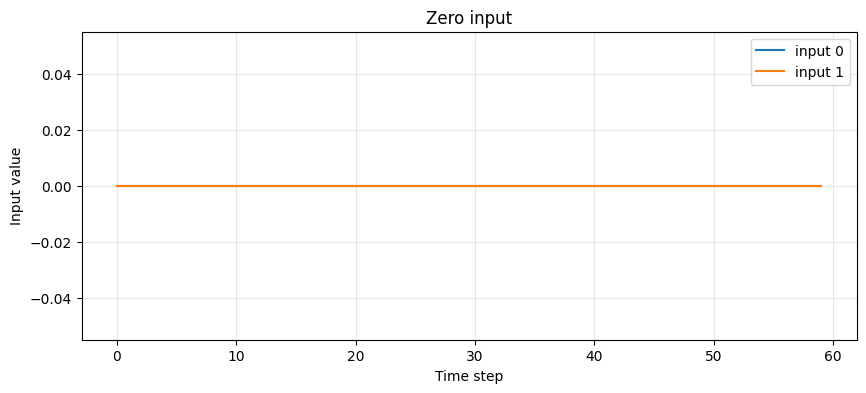

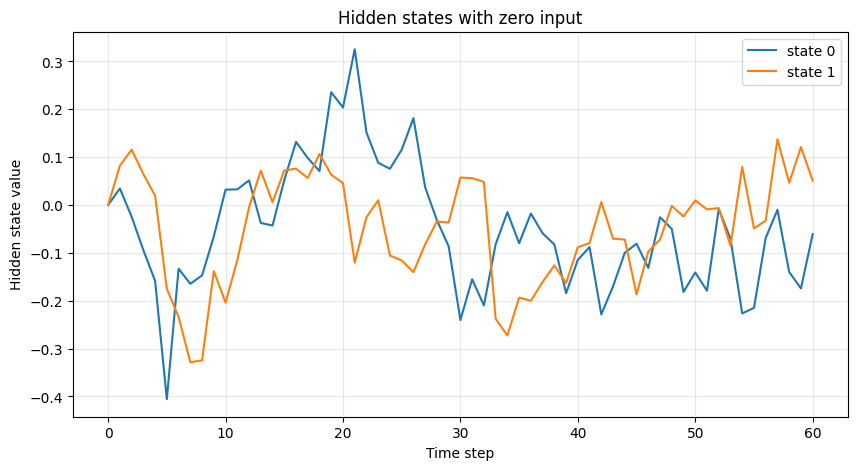

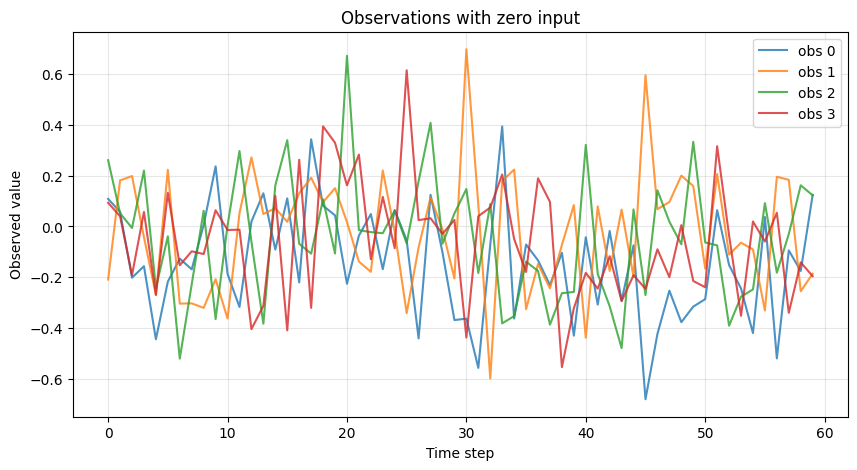

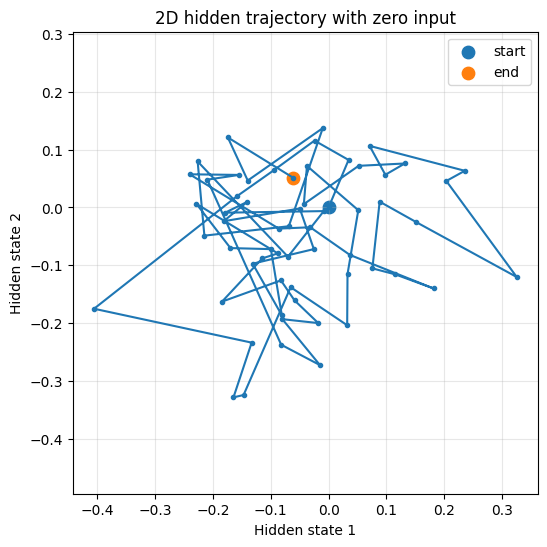

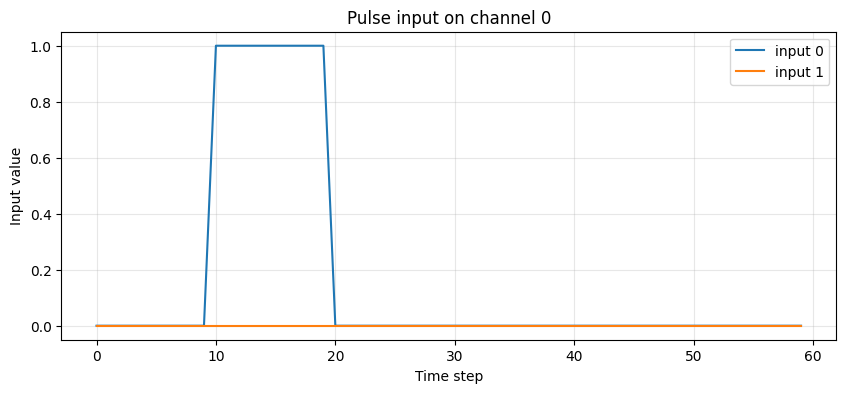

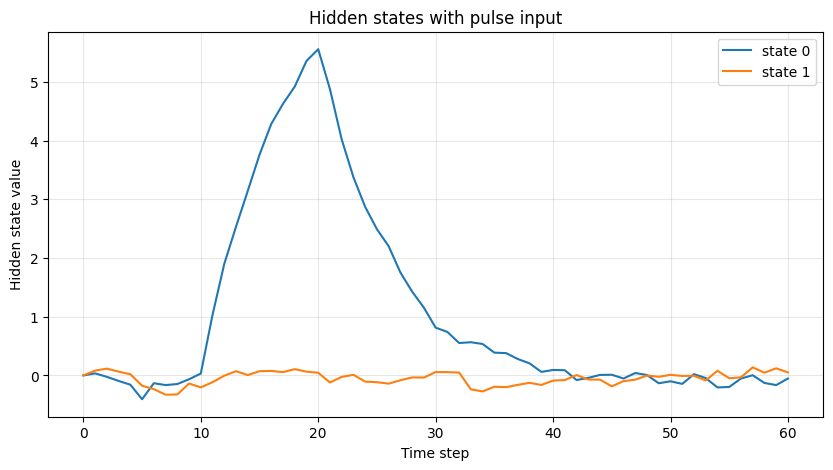

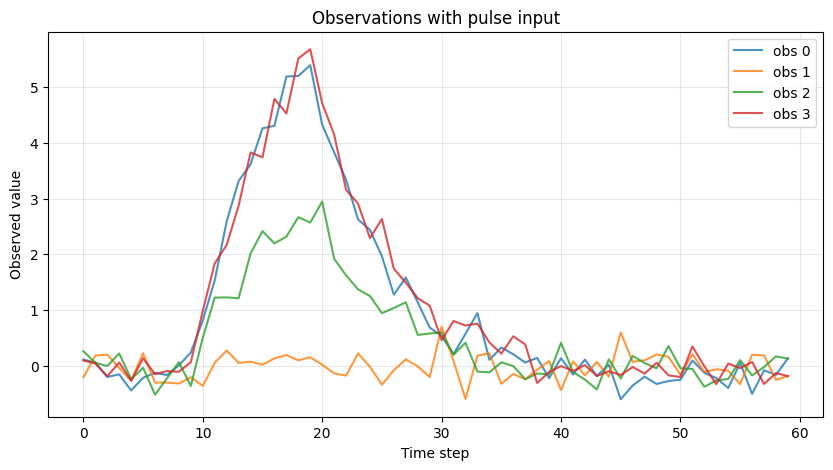

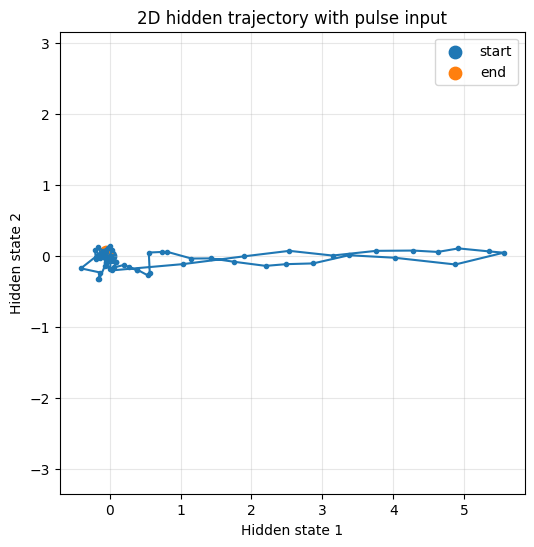

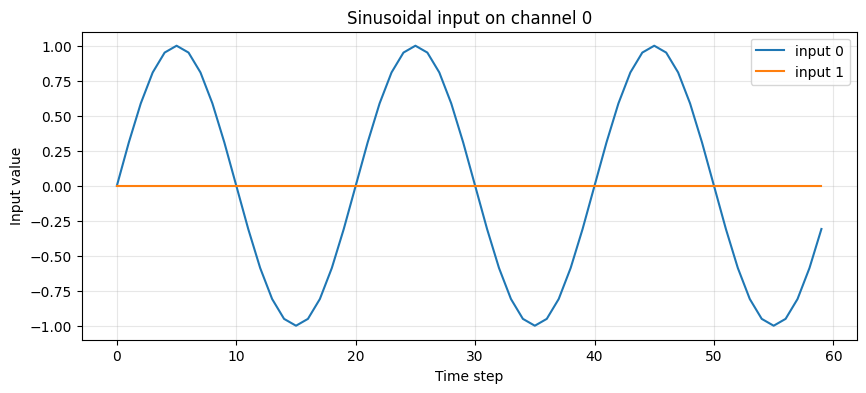

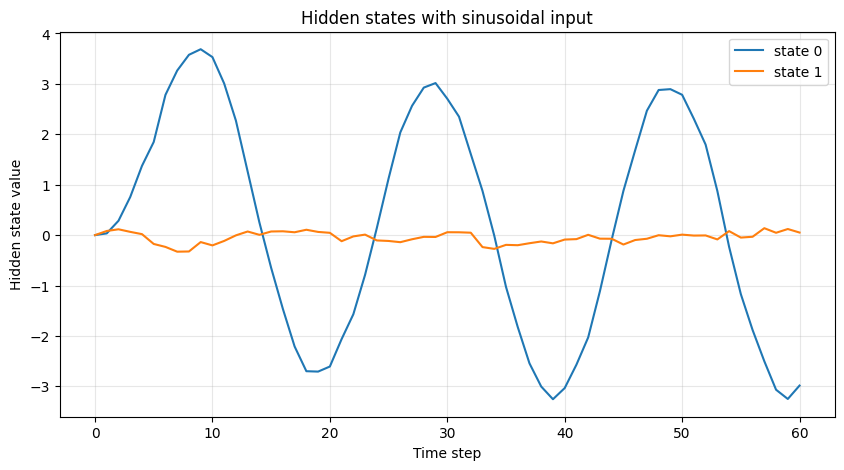

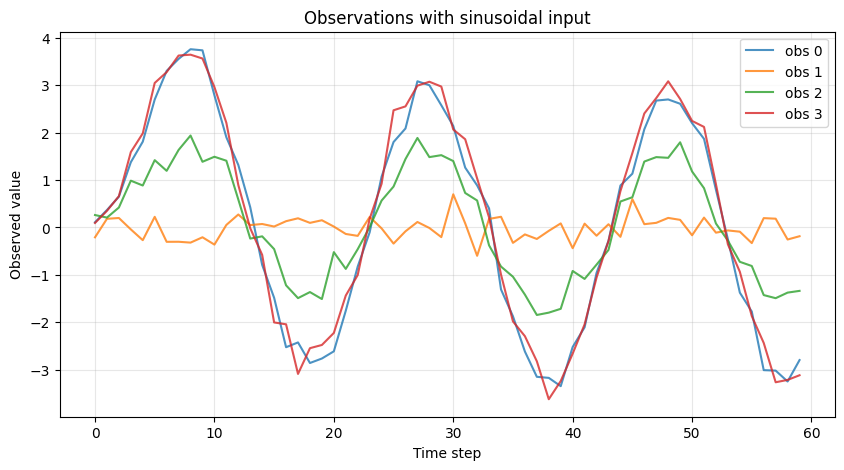

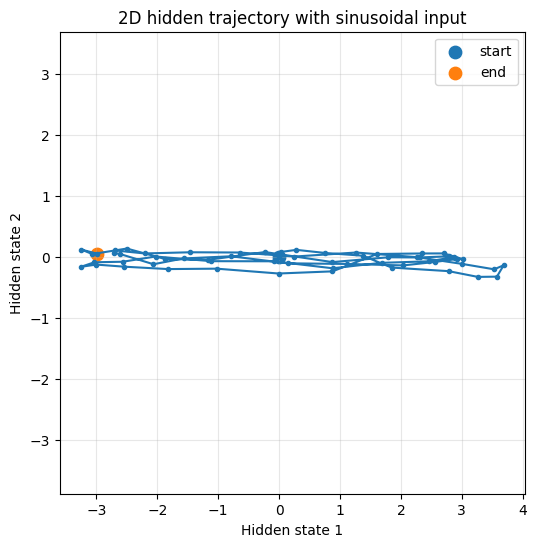

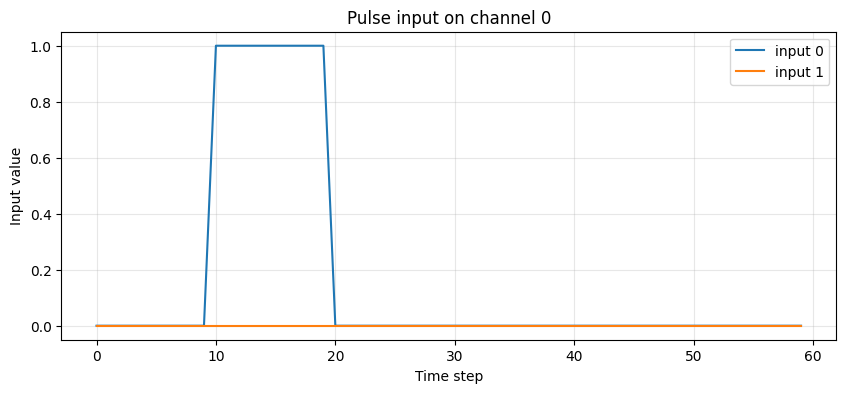

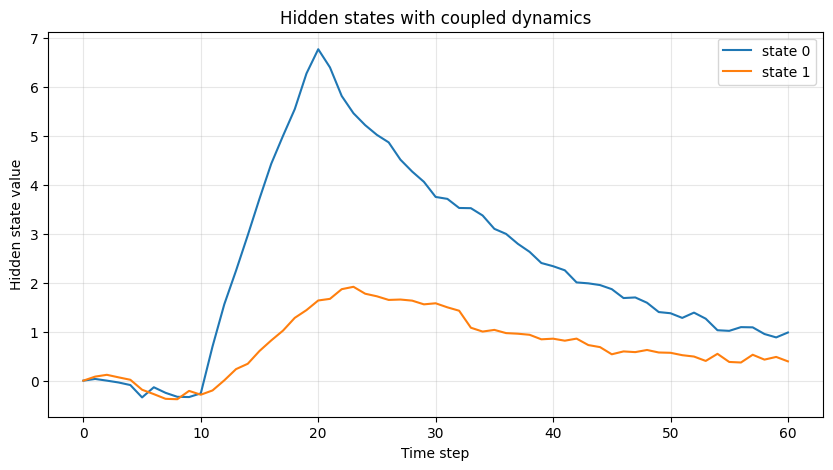

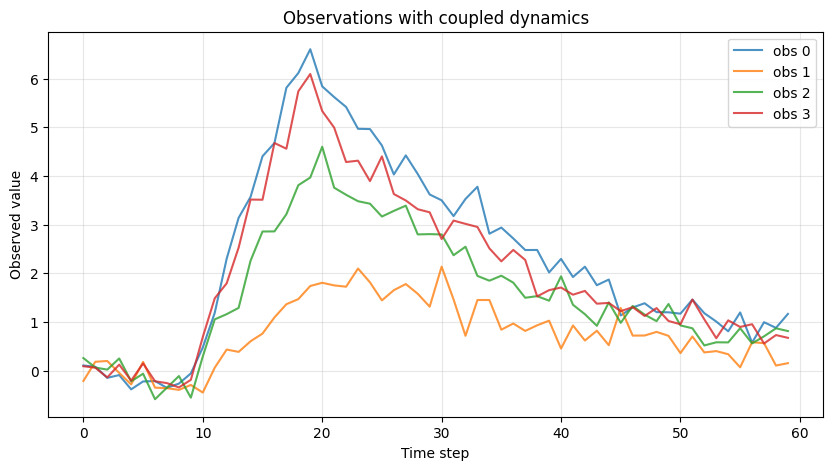

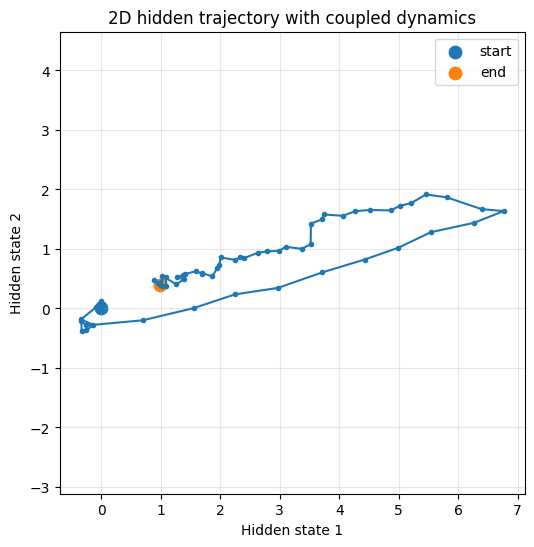

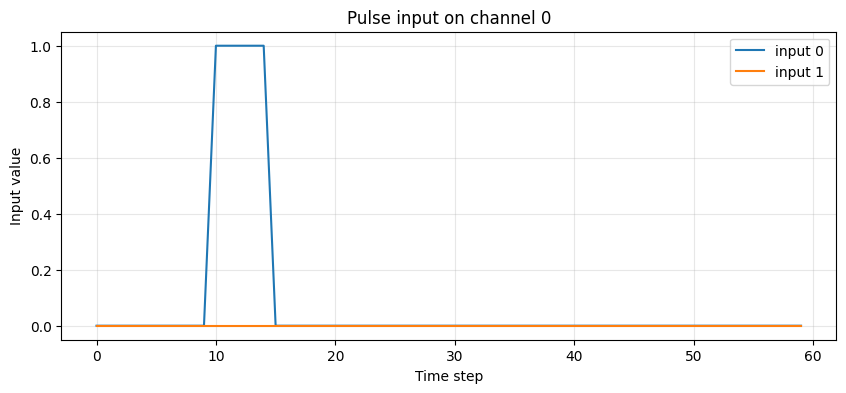

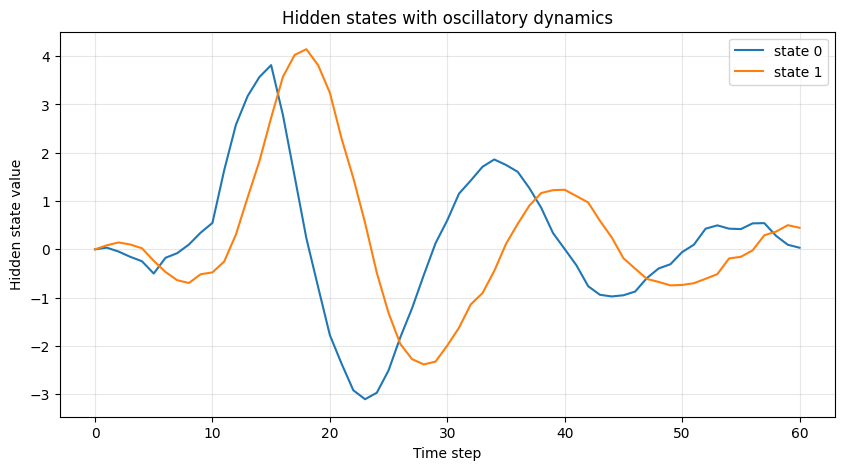

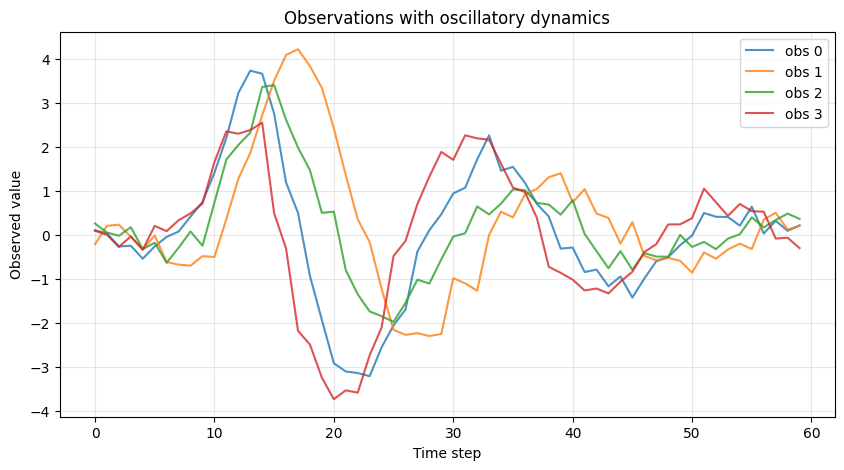

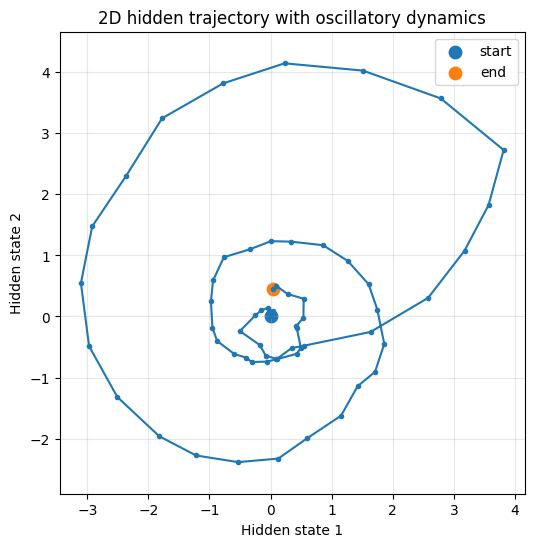

Dataset summary
----------------
Number of trials: 1
Number of timepoints per trial: 60
Number of neurons/signals: 4
Overall mean: 0.6273
Overall standard deviation: 1.3390
Minimum value: -0.6026
Maximum value: 5.6838


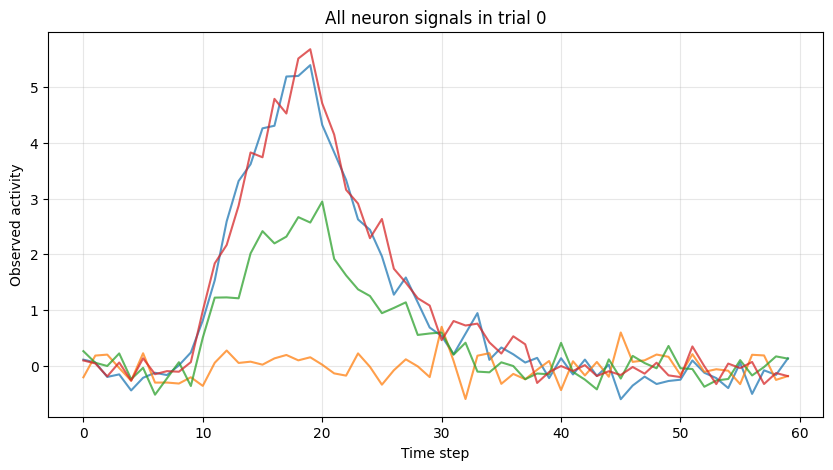

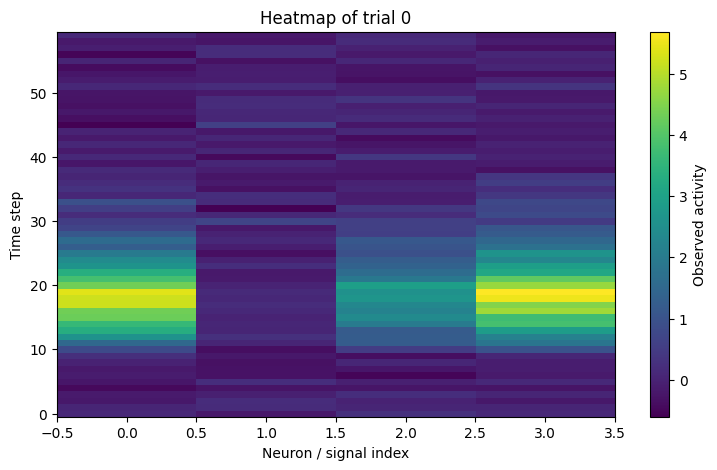

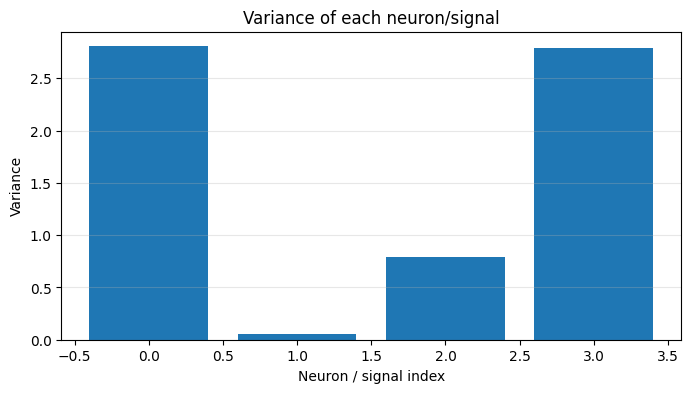